##  Table of Contents
* 1. [Libraries](#1)
* 2. [Dataset](#2)
* 3. [Feature Engineering](#3)
      * 3.1 [3.1 Perform column saperation](#3.1)
      * 3.2 [Transforming date and time variables to datetime](#3.2)
      * 3.3 [Creating 3 more variables: transaction_day, transaction_month, transaction_year](#3.3)
      * 3.4 [Creating 3 more variables: transaction_hour, transaction_minute, transaction_second](#3.4)
      * 3.5 [Total Revenue per Transaction](#3.5)
* 4. [Exploratory Data Analysis](#4)
      * 4.1 [Descriptive Statistics](#4.1)
      * 4.2 [Transactions by Day and Month](#4.2)
      * 4.3 [Transactions by Hour](#4.3)
      * 4.4 [Items Sold per Month](#4.4)
      * 4.5 [Transactions and Items sold per Store Location](#4.5)
      * 4.6 [Total Revenue by Store Location](#4.6)
      * 4.7 [Top Product Categories: Transactions vs Quantity Sold](#4.7)
      * 4.8 [Top Product Types: Transactions vs Quantity Sold](#4.8)
        * 4.8.1 [Comparison of product_type transactions vs quantity sold](#4.8.1)
      * 4.9 [Product Category Quantity Sold per Store Location](#4.9)
      * 4.10 [Product Revenue Analysis](#4.10)
        * 4.10.1 [Most Expensive Products on Average](#4.10.1)
        * 4.10.2 [Revenue by product category](#4.10.2)
        * 4.10.3 [Revenue by product type](#4.10.3)
        * 4.10.4 [Revenue by product category in each store location](#4.10.4)
        * 4.10.5 [Top 10 Products by: Revenue, Quantity Sold and Transactions](#4.10.5)
        * 4.10.6 [Hourly Revenue in each Store Location](#4.10.6)
        * 4.10.7 [Trend of Total Revenue Over Time](#4.10.7)
      * 4.11 [Relationship Between Unit Price, Transaction Quantity, and Total Revenue](#4.11)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
import seaborn as sns
from datetime import date
from datetime import datetime

## 2. Dataset <a id=2><a/>

In [2]:
df = pd.read_csv('coffee-shop-sales-revenue.csv')

In [3]:
df.head(5)

,transaction_id|transaction_date|transaction_time|transaction_qty|store_id|store_location|product_id|unit_price|product_category|product_type|product_detail
0,1|2023-01-01|07:06:11|2|5|Lower Manhattan|32|3...
1,2|2023-01-01|07:08:56|2|5|Lower Manhattan|57|3...
2,3|2023-01-01|07:14:04|2|5|Lower Manhattan|59|4...
3,4|2023-01-01|07:20:24|1|5|Lower Manhattan|22|2...
4,5|2023-01-01|07:22:41|2|5|Lower Manhattan|57|3...


## 3. Feature Engineering <a id=3><a/>

## 3.1 Perform column saperation <a id=3.1></a>

In [4]:
type(df.iloc[1,0])

str

In [5]:
transaction_id = []
transaction_date = []
transaction_time =[] 
transaction_qty =[]
store_id =[]
store_location =[]
product_id =[]
unit_price =[]
product_category =[]
product_type =[]
product_detail =[]

for i in range(0,df.shape[0]):
    l = df.iloc[i,0].split("|")
    transaction_id.append(l[0])
    transaction_date.append(l[1])
    transaction_time.append(l[2])
    transaction_qty.append(l[3])
    store_id.append(l[4])
    store_location.append(l[5])
    product_id.append(l[6])
    unit_price.append(l[7])
    product_category.append(l[8])
    product_type.append(l[9])
    product_detail.append(l[10])

In [6]:
dic = {
    "transaction_id" :transaction_id,
    "transaction_date" :transaction_date,
    "transaction_time" :transaction_time,
    "transaction_qty" :transaction_qty,
    "store_id" :store_id,
    "store_location" :store_location,
    "product_id" :product_id,
    "unit_price" :unit_price,
    "product_category" :product_category,
    "product_type" :product_type,
    "product_detail" :product_detail
}

In [7]:
df = pd.DataFrame(dic)

In [8]:
df.head()

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


## 3.2 Transforming date and time variables to datetime <a id=3.2></a>

In [9]:
df['transaction_time']= pd.to_datetime(df['transaction_time'], format='%H:%M:%S')
df['transaction_date']=pd.to_datetime(df['transaction_date'])
df

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2023-01-01,1900-01-01 07:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2023-01-01,1900-01-01 07:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2023-01-01,1900-01-01 07:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2023-01-01,1900-01-01 07:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2023-01-01,1900-01-01 07:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
...,...,...,...,...,...,...,...,...,...,...,...
149111,149452,2023-06-30,1900-01-01 20:18:41,2,8,Hell's Kitchen,44,2.5,Tea,Brewed herbal tea,Peppermint Rg
149112,149453,2023-06-30,1900-01-01 20:25:10,2,8,Hell's Kitchen,49,3.0,Tea,Brewed Black tea,English Breakfast Lg
149113,149454,2023-06-30,1900-01-01 20:31:34,1,8,Hell's Kitchen,45,3.0,Tea,Brewed herbal tea,Peppermint Lg
149114,149455,2023-06-30,1900-01-01 20:57:19,1,8,Hell's Kitchen,40,3.75,Coffee,Barista Espresso,Cappuccino


## 3.3 Creating 3 more variables: transaction_day, transaction_month, transaction_year <a id=3.3></a>

In [10]:


df['transaction_day'] = df['transaction_date'].dt.day_name()
df['transaction_month'] = df['transaction_date'].dt.month_name()
df['transaction_year'] = df['transaction_date'].dt.year

## 3.4 Creating 3 more variables: transaction_hour, transaction_minute, transaction_second <a id=3.4></a>

In [11]:

df['transaction_hour'] = df['transaction_time'].dt.hour
df['transaction_minute'] = df['transaction_time'].dt.minute
df['transaction_second'] = df['transaction_time'].dt.second

## 3.5 Total Revenue per Transaction <a id=3.5></a>

In [12]:
df['transaction_qty']=df['transaction_qty'].apply(float)
df['unit_price']=df['unit_price'].apply(float)

df['Total_revenue'] = df['transaction_qty'] * df['unit_price']
df.head(3)

,transaction_id,transaction_date,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail,transaction_day,transaction_month,transaction_year,transaction_hour,transaction_minute,transaction_second,Total_revenue
0,1,2023-01-01,1900-01-01 07:06:11,2.0,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg,Sunday,January,2023,7,6,11,6.0
1,2,2023-01-01,1900-01-01 07:08:56,2.0,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg,Sunday,January,2023,7,8,56,6.2
2,3,2023-01-01,1900-01-01 07:14:04,2.0,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg,Sunday,January,2023,7,14,4,9.0


## EDA <a id=4><a/>

## 4.1 Descriptive Statistics <a id=4.1></a>

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      149116 non-null  str    
 1   transaction_qty     149116 non-null  float64
 2   store_id            149116 non-null  str    
 3   store_location      149116 non-null  str    
 4   product_id          149116 non-null  str    
 5   unit_price          149116 non-null  float64
 6   product_category    149116 non-null  str    
 7   product_type        149116 non-null  str    
 8   product_detail      149116 non-null  str    
 9   transaction_day     149116 non-null  str    
 10  transaction_month   149116 non-null  str    
 11  transaction_year    149116 non-null  int32  
 12  transaction_hour    149116 non-null  int32  
 13  transaction_minute  149116 non-null  int32  
 14  transaction_second  149116 non-null  int32  
 15  Total_revenue       149116 non-null  float64


In [16]:
df.isnull().sum()

transaction_id        0
transaction_qty       0
store_id              0
store_location        0
product_id            0
unit_price            0
product_category      0
product_type          0
product_detail        0
transaction_day       0
transaction_month     0
transaction_year      0
transaction_hour      0
transaction_minute    0
transaction_second    0
Total_revenue         0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,transaction_qty,unit_price,transaction_year,transaction_hour,transaction_minute,transaction_second,Total_revenue
count,149116.000000,149116.000000,149116.0,149116.000000,149116.000000,149116.000000,149116.000000
mean,1.438276,3.382219,2023.0,11.735790,29.623863,29.541484,4.686367
std,0.542509,2.658723,0.0,3.764662,17.291357,17.297958,4.227099
min,1.000000,0.800000,2023.0,6.000000,0.000000,0.000000,0.800000
25%,1.000000,2.500000,2023.0,9.000000,15.000000,15.000000,3.000000
50%,1.000000,3.000000,2023.0,11.000000,30.000000,29.000000,3.750000
75%,2.000000,3.750000,2023.0,15.000000,45.000000,45.000000,6.000000
max,8.000000,45.000000,2023.0,20.000000,59.000000,59.000000,360.000000


## 4.2 Transactions by Day and Month <a id=4.2></a>

In [21]:
df.groupby('transaction_month')['transaction_day'].value_counts()

transaction_month  transaction_day
April              Sunday             4279
                   Saturday           4116
                   Wednesday          3517
                   Thursday           3417
                   Monday             3415
                   Tuesday            3390
                   Friday             3201
February           Sunday             2433
                   Monday             2373
                   Friday             2358
                   Wednesday          2350
                   Thursday           2325
                   Saturday           2321
                   Tuesday            2199
January            Monday             2814
                   Tuesday            2766
                   Sunday             2725
                   Friday             2291
                   Thursday           2283
                   Wednesday          2229
                   Saturday           2206
June               Friday             5960
                   

<Axes: xlabel='transaction_month'>

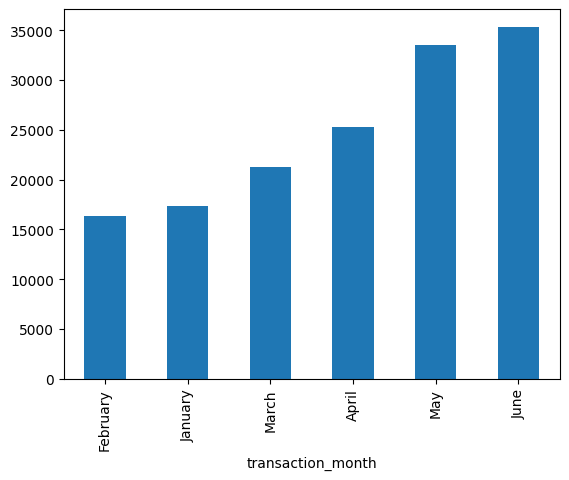

In [29]:
(df['transaction_month'].value_counts().sort_values()).plot(kind='bar')

##### Most transactions occur in June (35352).

## 4.3 Transactions by Hour <a id=4.3></a>

<Axes: xlabel='transaction_hour', ylabel='count'>

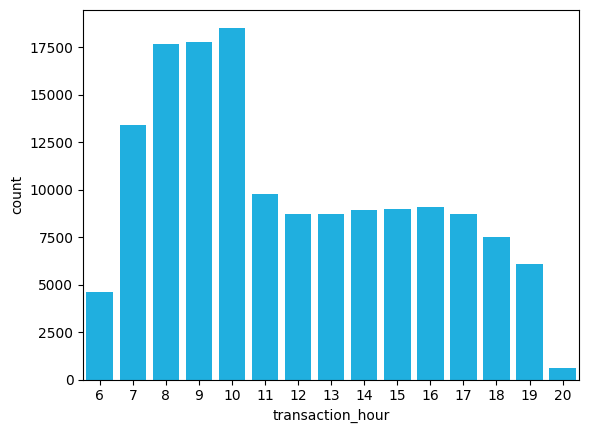

In [36]:
sns.countplot(data=df,x="transaction_hour",color="deepskyblue")

#### Most transactions happen in the morning hours (between 7:00-10:00).

## 4.4 Items Sold per Month <a id=4.4></a>


## 4.5 Transactions and Items sold per Store Location <a id=4.5></a>


## 4.6 Total Revenue by Store Location <a id=4.6></a>


## 4.7 Top Product Categories: Transactions vs Quantity Sold <a id=4.7></a>


## 4.8 Top Product Types: Transactions vs Quantity Sold <a id=4.8></a>


## 4.8.1 Comparison of product_type transactions vs quantity sold <a id=4.8.1></a>


## 4.9 Product Category Quantity Sold per Store Location <a id=4.9></a>


## 4.10 Product Revenue Analysis <a id=4.10></a>


## 4.10.1 Most Expensive Products on Average <a id=4.10.1></a>


## 4.10.2 Revenue by product category <a id=4.10.2></a>


## 4.10.3 Revenue by product type <a id=4.10.3></a>


## 4.10.4 Revenue by product category in each store location <a id=4.10.4></a>


## 4.10.5 Top 10 Products by: Revenue, Quantity Sold and Transactions <a id=4.10.5></a>


## 4.10.6 Hourly Revenue in each Store Location <a id=4.10.6></a>


## 4.10.7 Trend of Total Revenue Over Time <a id=4.10.7></a>


## 4.11 Relationship Between Unit Price, Transaction Quantity, and Total Revenue <a id=4.11></a>

(array([8.7159e+04, 5.8642e+04, 3.2790e+03, 0.0000e+00, 2.3000e+01,
        0.0000e+00, 0.0000e+00, 3.0000e+00, 0.0000e+00, 1.0000e+01]),
 array([1. , 1.7, 2.4, 3.1, 3.8, 4.5, 5.2, 5.9, 6.6, 7.3, 8. ]),
 <BarContainer object of 10 artists>)

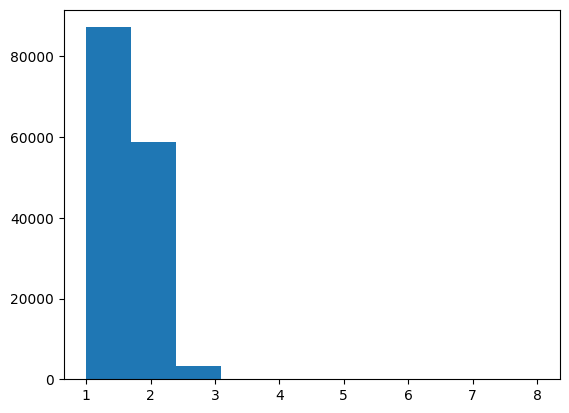

In [20]:
plt.hist(df['transaction_qty'],bins =10)
# outcome:- Maximum people comes alone or a group to two

In [ ]:
sns.distplot(df['transaction_qty'],hist = False)

# 3. store_id column

In [ ]:
sns.countplot(df['store_id'])

In [ ]:
df.head(5)

# Location wise test preference

In [ ]:
sns.heatmap(pd.crosstab(df['store_location'],df['product_category']))
#outcome :- Accross the all location customer preference coffee >> tea >> bakery

# Month wise test preference

In [ ]:
sns.heatmap(pd.crosstab(df['Month'],df['product_category']))
# outcome:- how coffee sales impact according to months
#         --> May and jun gives heighest sales for every category

# weekday wise test preference

In [ ]:
sns.heatmap(pd.crosstab(df['Weekday'],df['product_category']))

# Test preference in a day

In [ ]:
sns.heatmap(pd.crosstab(df['Time'],df['product_category']))

# Revenue from each store

In [ ]:
df.groupby("store_id").sum()['Money'].plot(kind = 'bar')

# heighest revenue giving category

In [ ]:
df.groupby("product_category").sum()['Money'].plot(kind = 'bar')
#coutcome :- coffee, tea and bakery giving heighest revenue

# items sold per month

In [ ]:
# df.groupby("Month").sum()['transaction_qty'].plot(kind = 'bar')

## 4.10 Product Revenue Analysis <a id=4.10></a>